In [1]:
!pip install numpy opencv-python matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import datetime
from tqdm.notebook import tqdm

In [8]:
# --- Settings --- 
video_path = 'short_20241023_TrepS_01_in (2).MOV'
threshold = 30
scale = 1
window_size = 5
pixel_threshold = 1000
output_path = 'short_'+video_path

In [9]:
# --- Open video ---
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Error: Could not open video.")
    cap.release()
    raise FileNotFoundError(f"Failed to load video: {video_path}")

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# --- Create video writer for output ---
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

Error: Could not open video.


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x55e996e9a440] moov atom not found


FileNotFoundError: Failed to load video: short_20241023_TrepS_01_in (2).MOV

In [4]:


total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
prev_gray = None
motion_counts = []
frame_idx = 0
saved_count = 0

start_time = datetime.datetime.now()

print("Starting video analysis...")
for _ in tqdm(range(total_frames), desc="Processing Frames"):
    ret, frame = cap.read()
    if not ret:
        break

    if scale != 1.0:
        frame = cv2.resize(frame, None, fx=scale, fy=scale)

    rgb = frame
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev_gray is not None:
        # --- Motion detection ---
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
        count_t = np.sum(mask > 0)
        motion_counts.append(count_t)
        
        if count_t > pixel_threshold:
            out.write(frame)
            saved_count += 1

    prev_gray = gray.copy()
    frame_idx += 1

cap.release()
out.release()
processing_time = (datetime.datetime.now() - start_time).total_seconds()
print(f"Analysis complete in {processing_time:.2f} seconds.")
print(f"{saved_count} frames saved to {output_path}.")

Starting video analysis...


Processing Frames:   0%|          | 0/66411 [00:00<?, ?it/s]

KeyboardInterrupt: 

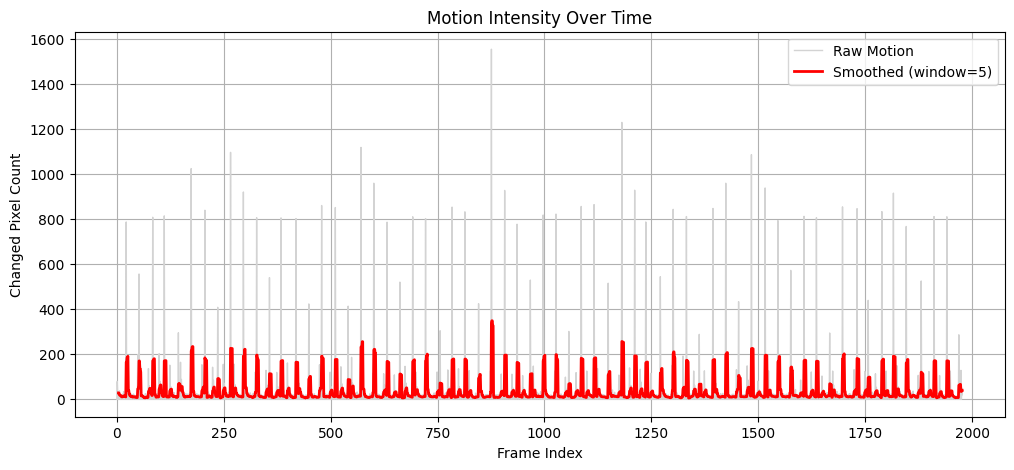

In [5]:

# --- Plot the motion intensity graph ---
smooth = np.convolve(motion_counts, np.ones(window_size) / window_size, mode='valid')
x_smooth = np.arange(window_size - 1, len(motion_counts))

plt.figure(figsize=(12, 5))
plt.plot(motion_counts, label="Raw Motion", color="lightgray", lw=1)
plt.plot(x_smooth, smooth, label=f"Smoothed (window={window_size})", color="red", lw=2)
plt.title("Motion Intensity Over Time")
plt.xlabel("Frame Index")
plt.ylabel("Changed Pixel Count")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# --- Display captured frames (optional) ---
if save_visual_frames and combined_frames:
    print(f"Displaying {len(combined_frames)} frames with high motion activity...")
    for idx, img in enumerate(combined_frames):
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.title(f"Processed Frame #{idx + 1}")
        plt.axis("off")
        plt.show()

NameError: name 'save_visual_frames' is not defined